<a href="https://www.kaggle.com/code/skailshvenkat/fem-fdm?scriptVersionId=227362893" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image  

dataset_path = '/kaggle/input/normal/NORMAL' 
image_size = (128, 128)  # Target image size

def load_images(dataset_path, image_size=(128, 128)):
    images = []
    for img_name in os.listdir(dataset_path):
        img_path = os.path.join(dataset_path, img_name)
        img = image.load_img(img_path, target_size=image_size)  
        img = image.img_to_array(img)  
        img = img / 255.0 
        images.append(img)
    return np.array(images)

images = load_images(dataset_path)


In [4]:
X_train, X_test = train_test_split(images, test_size=0.2, random_state=42)

In [29]:
from tensorflow.keras import layers, models

def res_block(x, filters, use_bn=True, dropout_rate=0.0):
    shortcut = x
    x = layers.Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0.0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(filters, (3, 3), padding="same", activation=None)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Add()([shortcut, x])
    x = layers.Activation("relu")(x)
    return x

def build_complex_encoder(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), strides=2, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 64, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2D(128, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 128, use_bn=True, dropout_rate=0.1)

    x = layers.Flatten()(x)
    latent = layers.Dense(256, activation="relu")(x)

    return models.Model(inputs, latent, name="Complex_Encoder")



In [30]:
def build_complex_decoder(latent_dim=256, target_shape=(128, 128, 3)):
    inputs = layers.Input(shape=(latent_dim,))

    x = layers.Dense(16 * 16 * 128, activation="relu")(inputs)
    x = layers.Reshape((16, 16, 128))(x)

    x = layers.Conv2DTranspose(128, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 128, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2DTranspose(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 64, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2DTranspose(32, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(target_shape[-1], (3, 3), padding="same", activation="sigmoid")(x)

    return models.Model(inputs, x, name="Complex_Decoder")



In [31]:
def build_autoencoder(input_shape=(128, 128, 3)):
    encoder = build_complex_encoder(input_shape)
    decoder = build_complex_decoder(latent_dim=256, target_shape=input_shape)

    inputs = layers.Input(shape=input_shape)
    latent = encoder(inputs)
    reconstructed = decoder(latent)

    autoencoder = models.Model(inputs, reconstructed, name="Autoencoder")
    autoencoder.compile(optimizer="adam", loss="mean_squared_error")
    return autoencoder



In [32]:
autoencoder = build_autoencoder(input_shape=(128, 128, 3))
autoencoder.summary()

autoencoder.fit(
    X_train, X_train,
    validation_data=(X_test, X_test),
    epochs=67,
    batch_size=16,
)


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Complex_Encoder (Functional)         │ (None, 256)                 │       8,853,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Complex_Decoder (Functional)         │ (None, 128, 128, 3)         │       9,033,539 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,887,107 (68.23 MB)

 Trainable params: 17,884,675 (68.22 MB)

 Non-trainable params: 2,432 (9.50 KB)

Epoch 1/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 170ms/step - loss: 0.0383 - val_loss: 0.0443
Epoch 2/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0136 - val_loss: 0.0319
Epoch 3/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0100 - val_loss: 0.0250
Epoch 4/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0085 - val_loss: 0.0134
Epoch 5/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0075 - val_loss: 0.0128
Epoch 6/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0068 - val_loss: 0.0083
Epoch 7/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0065 - val_loss: 0.0079
Epoch 8/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0062 - val_loss: 0.0070
Epoch 9/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.0060 - val_loss: 0.0061
Epoch 10/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.0055 - val_loss: 0.0060
Epoch 11/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0056 - val_loss: 0.0070
Epoch 12/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step


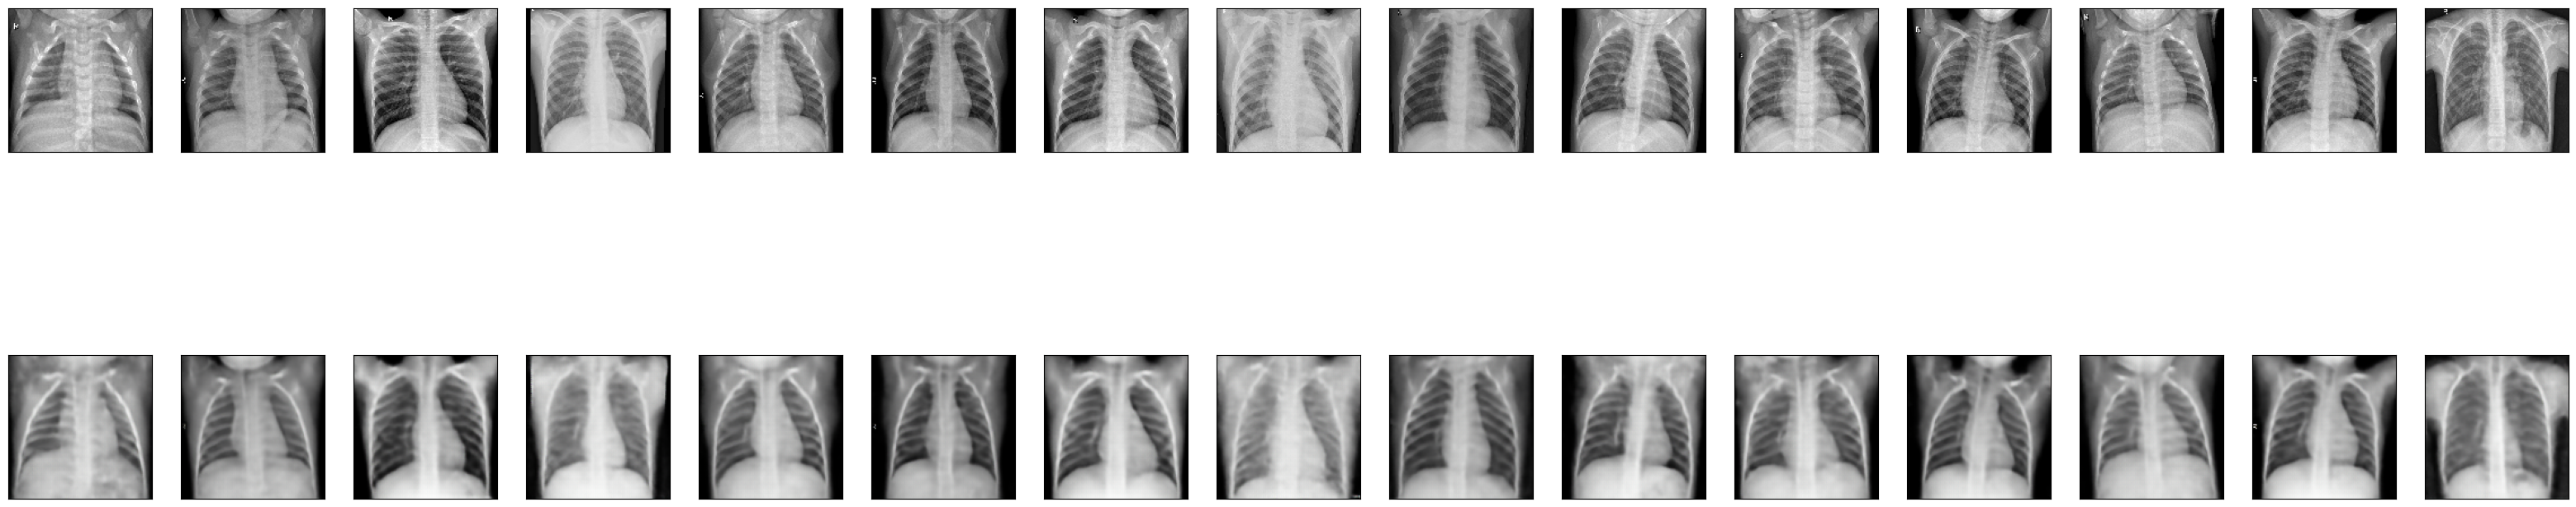

In [33]:
decoded_imgs = autoencoder.predict(X_test)

n = 15  
plt.figure(figsize=(40, 10))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


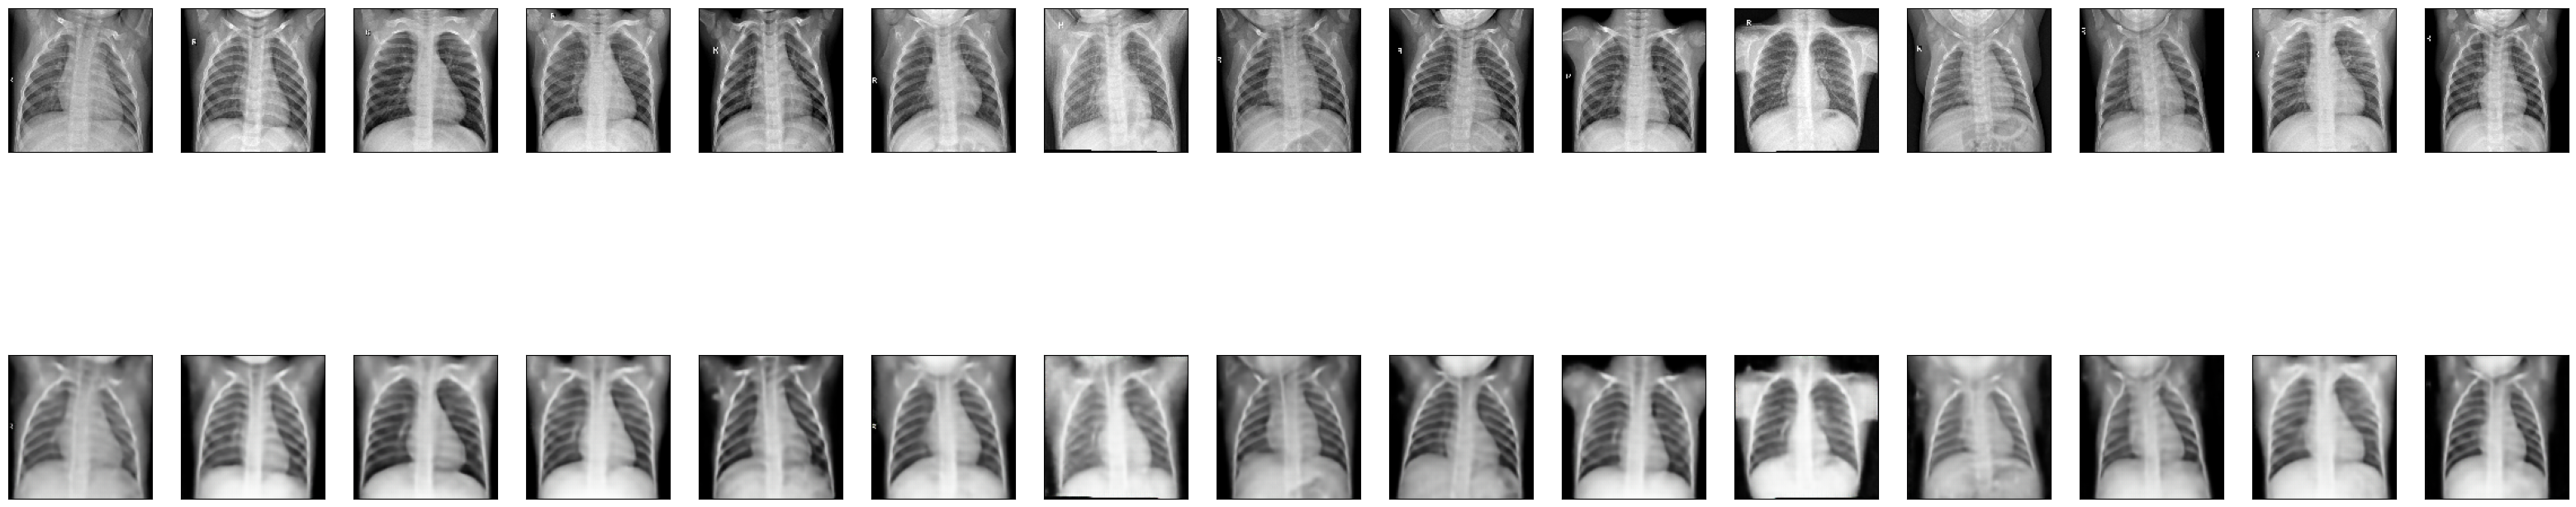

In [34]:
decoded_imgs = autoencoder.predict(X_train)

n = 15  
plt.figure(figsize=(40, 10))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_train[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


In [35]:
encoder = autoencoder.get_layer("Complex_Encoder")
encoder.summary() 

Model: "Complex_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_22 (Conv2D)        │ (None, 64, 64, 32)     │            896 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_28    │ (None, 64, 64, 32)     │            128 │ conv2d_22[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_23 (Conv2D)        │ (None, 32, 32, 64)     │         18,496 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_29    │ (None, 32, 32, 64)     │            256 │ conv2d_23[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_24 (Conv2D)        │ (None, 32, 32, 64)     │         36,928 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_30    │ (None, 32, 32, 64)     │            256 │ conv2d_24[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_8 (Dropout)       │ (None, 32, 32, 64)     │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_25 (Conv2D)        │ (None, 32, 32, 64)     │         36,928 │ dropout_8[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_31    │ (None, 32, 32, 64)     │            256 │ conv2d_25[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_8 (Add)               │ (None, 32, 32, 64)     │              0 │ batch_normalization_2… │
│                           │                        │                │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_8 (Activation) │ (None, 32, 32, 64)     │              0 │ add_8[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_26 (Conv2D)        │ (None, 16, 16, 128)    │         73,856 │ activation_8[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_32    │ (None, 16, 16, 128)    │            512 │ conv2d_26[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_27 (Conv2D)        │ (None, 16, 16, 128)    │        147,584 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_33    │ (None, 16, 16, 128)    │            512 │ conv2d_27[0][0]        │
│ (BatchNormalization) 

 Total params: 8,853,568 (33.77 MB)

 Trainable params: 8,852,352 (33.77 MB)

 Non-trainable params: 1,216 (4.75 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


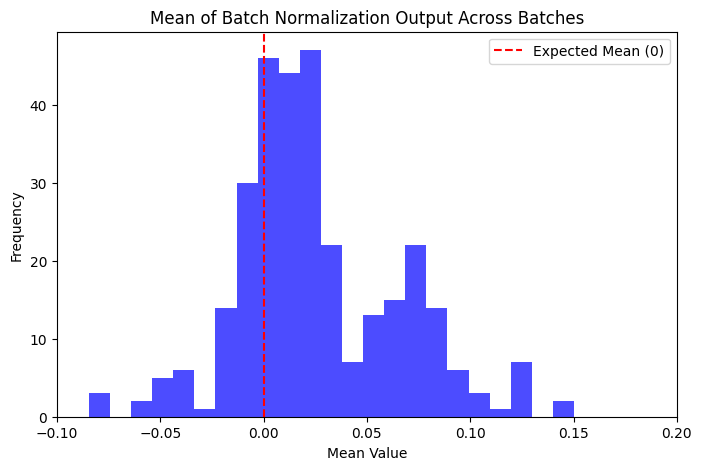

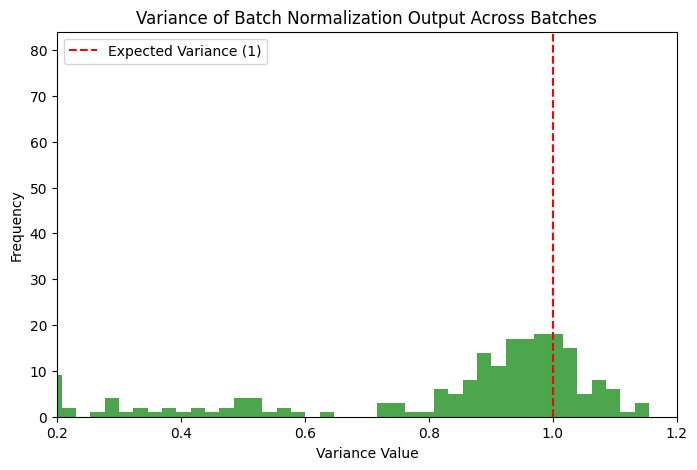

Mean range: -0.08450471609830856 to 0.42571133375167847
Variance range: 3.1908297387417406e-05 to 1.1548824310302734

Gamma (Scale) values:
[0.9493883  1.0140135  0.9824975  1.063604   1.0117812  0.97371453
 0.9613742  0.97357523 0.9661131  1.018046   0.9973307  0.95449686
 0.9515813  0.98854315 1.0513434  1.0013508  0.943324   0.96654785
 0.9783507  1.0099436  1.0088106  1.0224727  0.9588142  1.0780777
 1.0227964  1.0061405  0.96549124 1.0135792  0.99559844 0.978154
 0.9350296  0.930445  ]

Beta (Shift) values:
[-0.01022878 -0.08631699 -0.01800196  0.0320559   0.03045997  0.03344823
 -0.00455662  0.00693367  0.00173199  0.01104906  0.01506681  0.00531256
  0.01328082 -0.01361423  0.00885948 -0.01818211  0.01167002  0.01288998
 -0.00019065 -0.00665206 -0.01454177  0.01129323  0.00335622 -0.01912768
  0.01859144  0.00615212  0.01677333 -0.00973102  0.00549401  0.00437079
  0.00243384  0.02274768]


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import Model

# Select the batch normalization layer you want to inspect
layer_name = "batch_normalization_28"  # Change this to the layer you want to inspect

# Create a model that outputs the activations of the batch norm layer
intermediate_model = Model(inputs=encoder.input, outputs=encoder.get_layer(layer_name).output)

# Extract gamma and beta values
bn_layer = encoder.get_layer(layer_name)
gamma, beta = bn_layer.get_weights()[0], bn_layer.get_weights()[1]

# Define the number of batches to process
num_batches = 10
batch_size = 16

mean_list = []
var_list = []

for i in range(num_batches):
    sample_batch = X_train[i * batch_size : (i + 1) * batch_size]  # Extract batch
    activations = intermediate_model.predict(sample_batch)

    # Compute mean and variance
    mean_values = np.mean(activations, axis=(0, 1, 2))
    var_values = np.var(activations, axis=(0, 1, 2))

    mean_list.extend(mean_values)
    var_list.extend(var_values)

# Convert lists to numpy arrays
mean_list = np.array(mean_list)
var_list = np.array(var_list)

# Plot mean distribution
plt.figure(figsize=(8, 5))
plt.hist(mean_list, bins=50, color='b', alpha=0.7)
plt.axvline(0, color='r', linestyle="--", label="Expected Mean (0)")
plt.title("Mean of Batch Normalization Output Across Batches")
plt.xlabel("Mean Value")
plt.ylabel("Frequency")
plt.xlim(-0.1,0.2)
plt.legend()
plt.show()

# Plot variance distribution
plt.figure(figsize=(8, 5))
plt.hist(var_list, bins=50, color='g', alpha=0.7)
plt.axvline(1, color='r', linestyle="--", label="Expected Variance (1)")
plt.title("Variance of Batch Normalization Output Across Batches")
plt.xlabel("Variance Value")
plt.ylabel("Frequency")
plt.xlim(0.2,1.2)
plt.legend()
plt.show()

# Print mean and variance ranges
print(f"Mean range: {mean_list.min()} to {mean_list.max()}")
print(f"Variance range: {var_list.min()} to {var_list.max()}")

# Print gamma and beta values
print("\nGamma (Scale) values:")
print(gamma)

print("\nBeta (Shift) values:")
print(beta)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step
Feature Maps Shape: (1, 32, 32, 64)


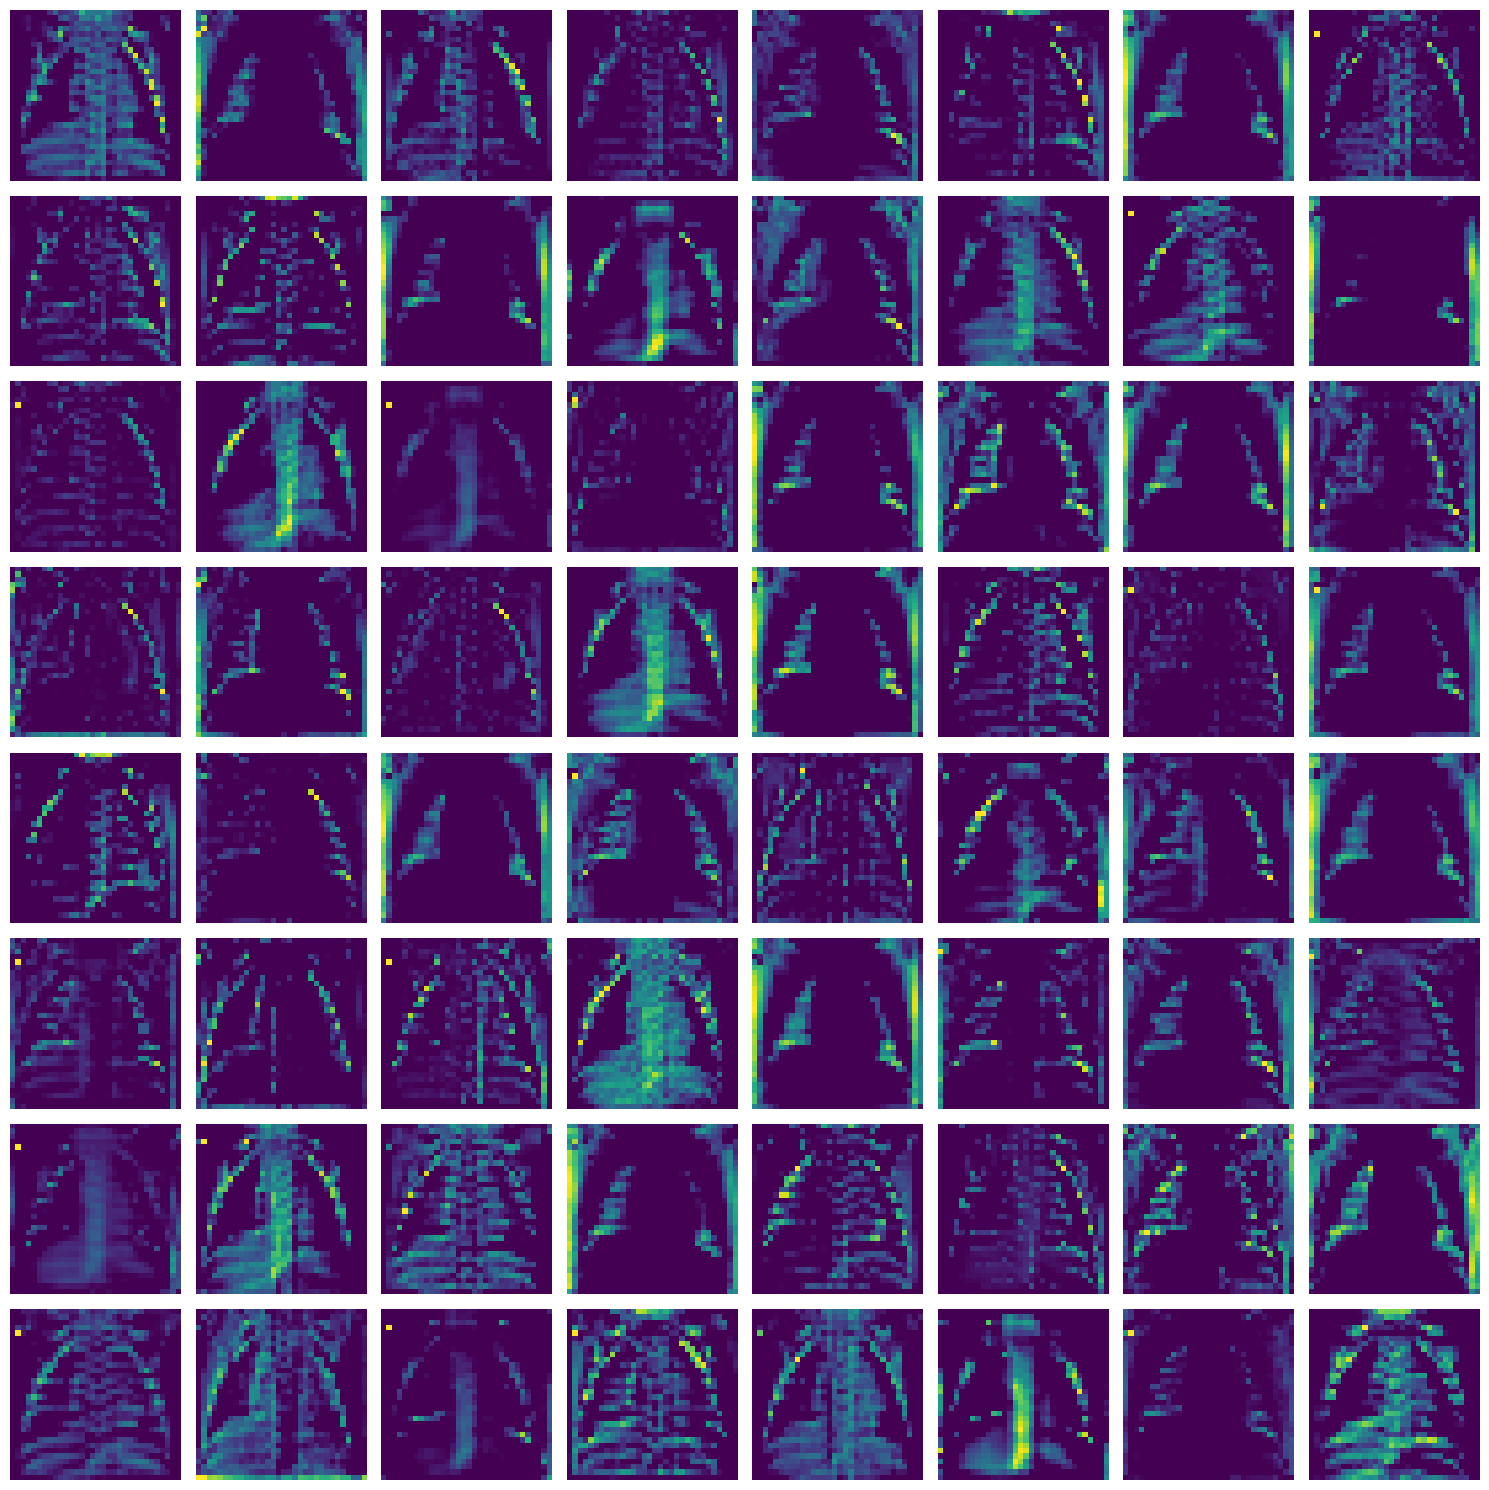

In [12]:
from keras.models import Model

conv_layer_name = "activation"
feature_map_model = Model(inputs=encoder.input, outputs=encoder.get_layer(conv_layer_name).output)

test_image = X_test[0:1] 
feature_maps = feature_map_model.predict(test_image)

print(f"Feature Maps Shape: {feature_maps.shape}")  

def plot_feature_maps(feature_maps):
    num_maps = feature_maps.shape[-1]  
    grid_size = int(np.ceil(np.sqrt(num_maps)))  

    plt.figure(figsize=(15, 15))
    for i in range(num_maps):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_feature_maps(feature_maps)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
Feature Maps Shape: (1, 16, 16, 128)


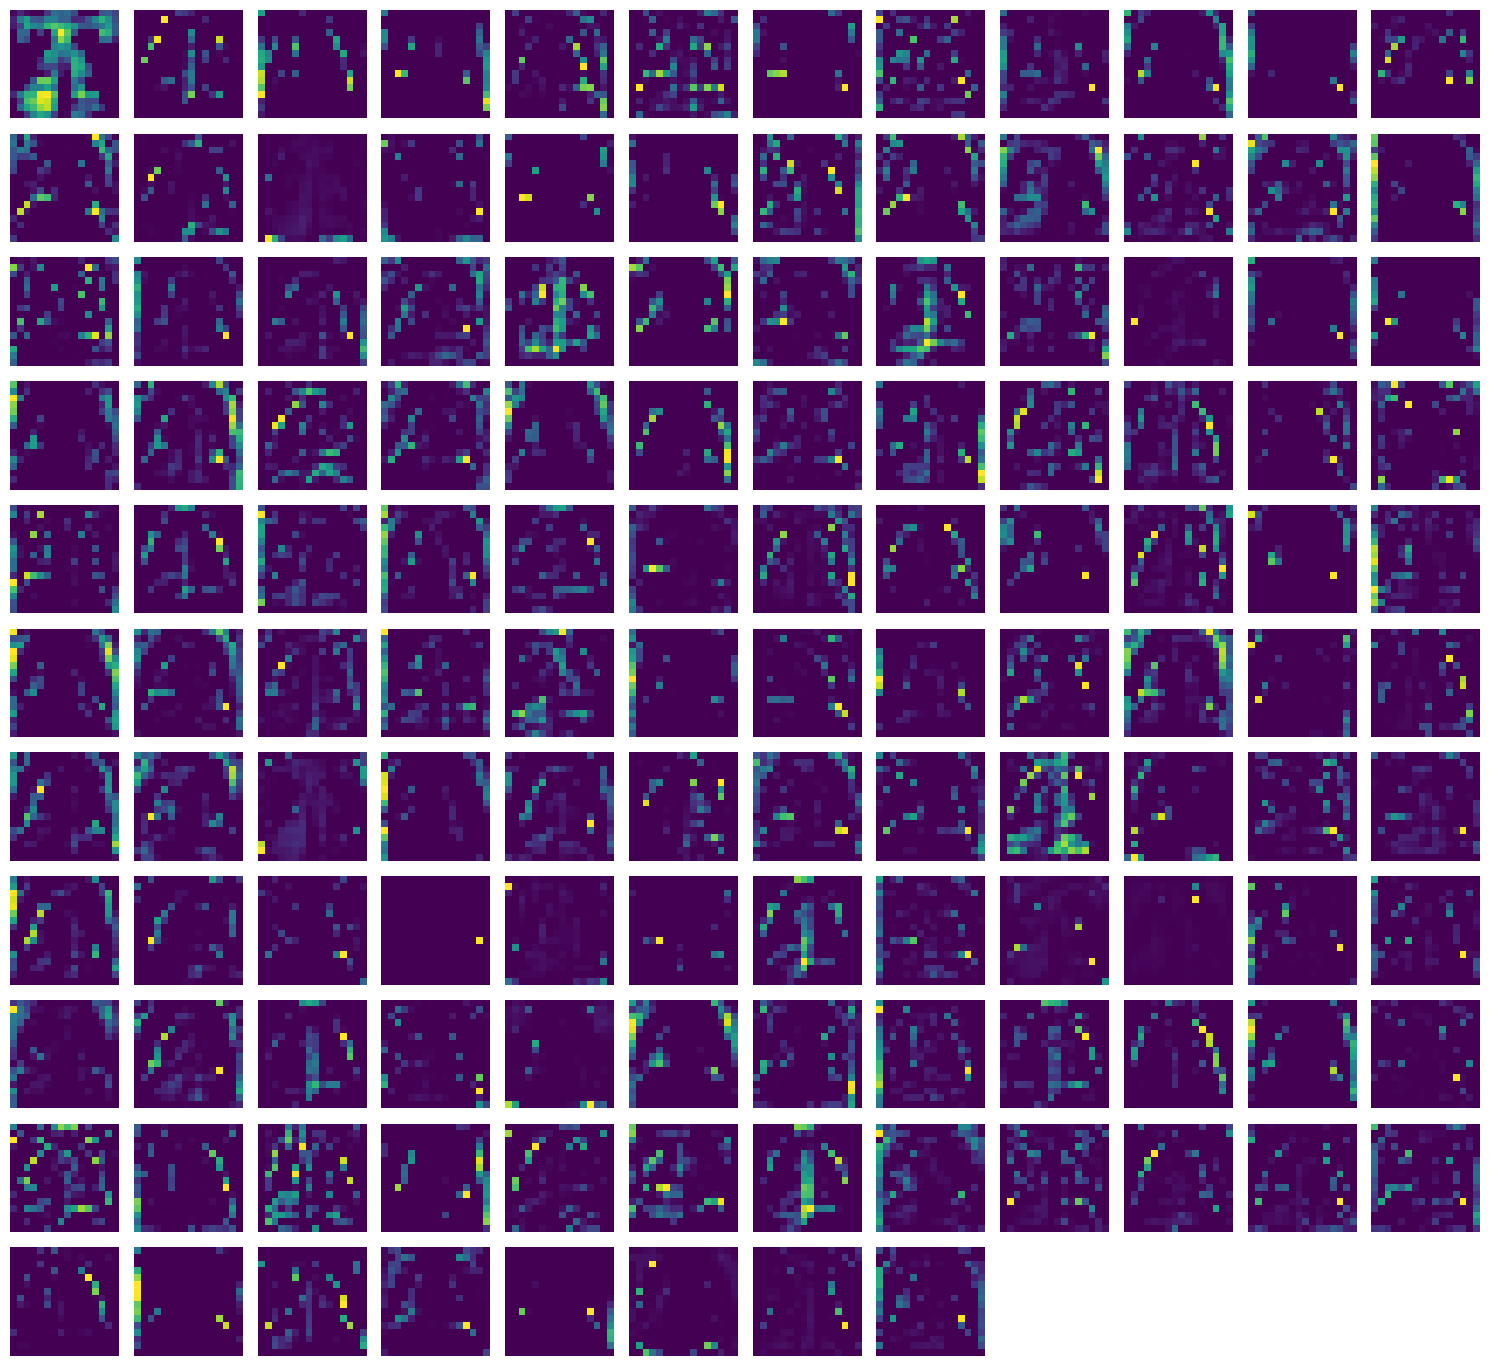

In [13]:
from keras.models import Model

conv_layer_name = "activation_1"
feature_map_model1 = Model(inputs=encoder.input, outputs=encoder.get_layer(conv_layer_name).output)

test_image = X_test[0:1] 
feature_maps = feature_map_model1.predict(test_image)

print(f"Feature Maps Shape: {feature_maps.shape}")  # Expected: (1, 16, 16, 128)

def plot_feature_maps(feature_maps):
    num_maps = feature_maps.shape[-1]  
    grid_size = int(np.ceil(np.sqrt(num_maps))) 

    plt.figure(figsize=(15, 15))
    for i in range(num_maps):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_feature_maps(feature_maps)


In [14]:
import numpy as np
from tensorflow.keras.models import Model

conv_layer_name = "dense"
latent_model = Model(inputs=encoder.input, outputs=encoder.get_layer(conv_layer_name).output)

latent_vectors = latent_model.predict(X_test[:10])

for i, vector in enumerate(latent_vectors):
    print(f"Latent vector for test image {i + 1}:")
    print(vector)
    print("-" * 50)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Latent vector for test image 1:
[ 43.367058    50.60651      0.           0.           0.
  12.473841     0.           0.          46.52211      0.
   2.3592813    0.           0.           0.           5.4996
   5.202353    12.178762     0.           0.          22.937435
   9.302736     0.           0.           0.           0.
   0.           0.           0.          49.84823      0.
   0.           0.           0.           0.           0.
   0.           0.          80.46569      0.           0.
   0.           0.          27.586704     0.           0.
  58.040207     0.         156.71243      0.           0.
  21.995302     0.          69.661446     0.           0.
   0.           0.           0.           0.          54.160275
   0.           0.           0.          33.773373     0.
  14.895064     0.          45.48229     73.60087      0.
   0.9839436   30.669012     0.          43.574455     0.
   0.           0.           0.           0.  

In [15]:
decoder = autoencoder.get_layer("Complex_Decoder")
decoder.summary() 

Model: "Complex_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 256)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 32768)          │      8,421,376 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 16, 16, 128)    │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose          │ (None, 32, 32, 128)    │        147,584 │ reshape[0][0]          │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_7     │ (None, 32, 32, 128)    │            512 │ conv2d_transpose[0][0] │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 32, 32, 128)    │        147,584 │ batch_normalization_7… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_8     │ (None, 32, 32, 128)    │            512 │ conv2d_7[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 32, 32, 128)    │              0 │ batch_normalization_8… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 32, 32, 128)    │        147,584 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_9     │ (None, 32, 32, 128)    │            512 │ conv2d_8[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, 32, 32, 128)    │              0 │ batch_normalization_7… │
│                           │                        │                │ batch_normalization_9… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 32, 32, 128)    │              0 │ add_2[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_1        │ (None, 64, 64, 64)     │         73,792 │ activation_2[0][0]     │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_10    │ (None, 64, 64, 64)     │            256 │ conv2d_transpose_1[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 64, 64, 64)     │         36,928 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1

 Total params: 9,033,539 (34.46 MB)

 Trainable params: 9,032,323 (34.46 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [16]:
latent_vectors.shape

(10, 256)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step


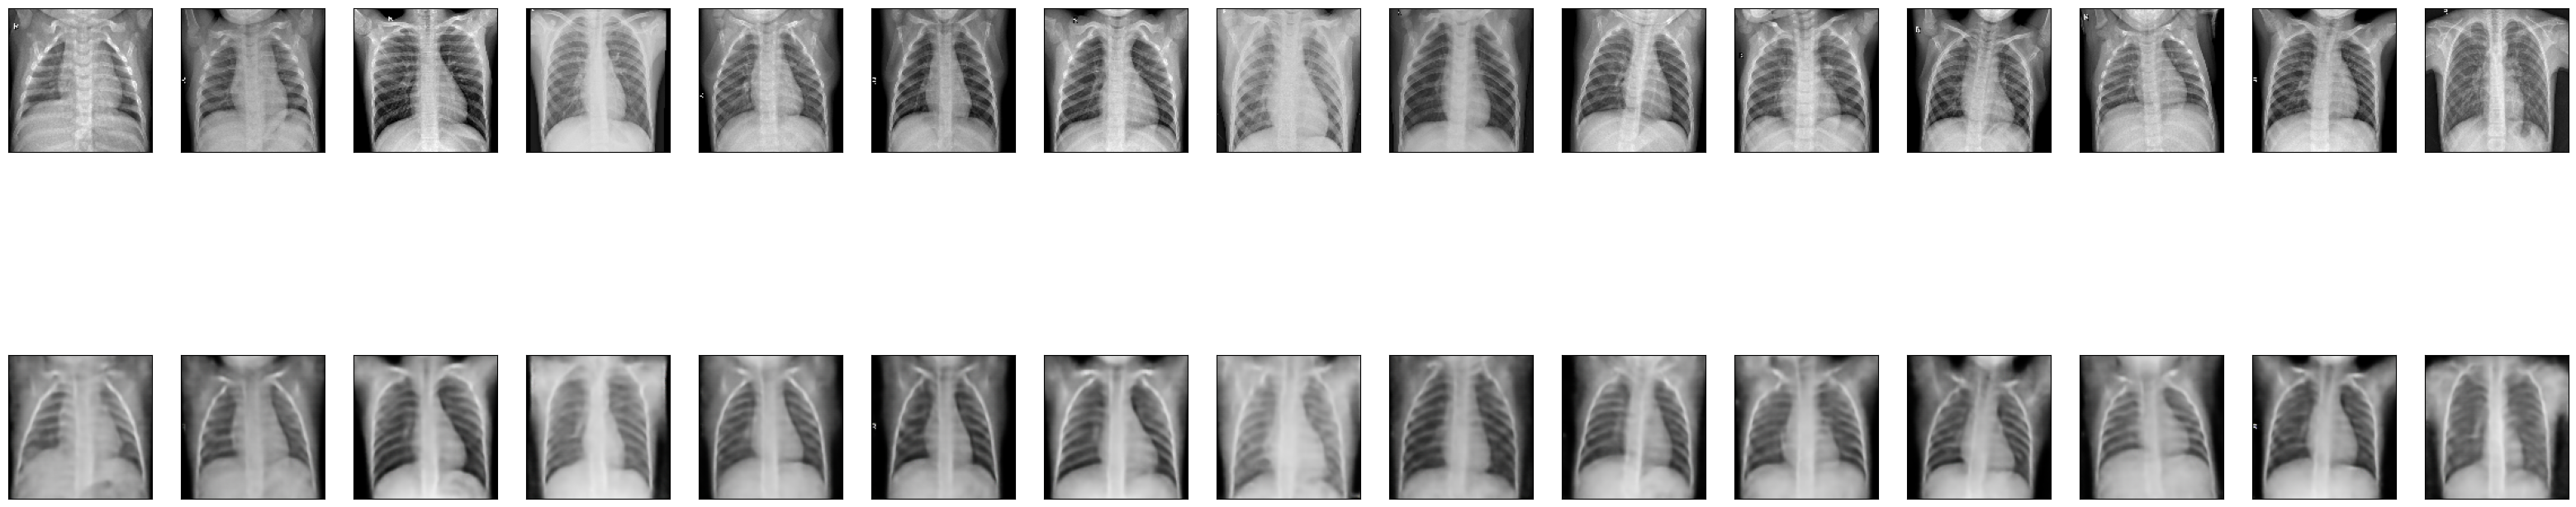

In [17]:
encoder = autoencoder.get_layer("Complex_Encoder")  
decoder = autoencoder.get_layer("Complex_Decoder")  

encoded_data = encoder.predict(X_test)

y_test = decoder.predict(encoded_data)

n = 15 
plt.figure(figsize=(40, 10))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(y_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [18]:
encoded_data.shape

(315, 256)

In [19]:
from tensorflow.keras import layers, models

def res_block(x, filters, use_bn=True, dropout_rate=0.0):
    shortcut = x
    x = layers.Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0.0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(filters, (3, 3), padding="same", activation=None)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Add()([shortcut, x])
    x = layers.Activation("relu")(x)
    return x

def build_encoder(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), strides=2, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 64, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2D(128, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 128, use_bn=True, dropout_rate=0.1)

    # No Flatten, keeping feature maps
    return models.Model(inputs, x, name="Encoder")

def build_decoder(target_shape=(128, 128, 3)):
    inputs = layers.Input(shape=(16, 16, 128))  # Assuming feature maps size here

    x = layers.Conv2DTranspose(128, (3, 3), strides=2, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 128, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2DTranspose(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 64, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2DTranspose(32, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(target_shape[-1], (3, 3), padding="same", activation="sigmoid")(x)

    return models.Model(inputs, x, name="Decoder")

In [20]:
def build_autoencoder(input_shape=(128, 128, 3)):
    encoder = build_encoder(input_shape)
    decoder = build_decoder(target_shape=input_shape)

    inputs = layers.Input(shape=input_shape)
    feature_maps = encoder(inputs)  # Outputs feature maps
    reconstructed = decoder(feature_maps)  # Decoder takes feature maps as input

    autoencoder = models.Model(inputs, reconstructed, name="Autoencoder")
    autoencoder.compile(optimizer="adam", loss="mean_squared_error")
    return autoencoder

autoencoder = build_autoencoder(input_shape=(128, 128, 3))
autoencoder.summary()

# Training the autoencoder
autoencoder.fit(
    X_train, X_train,
    validation_data=(X_test, X_test),
    epochs=67,
    batch_size=16,
) 


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Encoder (Functional)                 │ (None, 16, 16, 128)         │         464,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Decoder (Functional)                 │ (None, 128, 128, 3)         │         612,163 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,076,867 (4.11 MB)

 Trainable params: 1,074,435 (4.10 MB)

 Non-trainable params: 2,432 (9.50 KB)

Epoch 1/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 31s 181ms/step - loss: 0.0265 - val_loss: 0.0349
Epoch 2/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0037 - val_loss: 0.0330
Epoch 3/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0027 - val_loss: 0.0217
Epoch 4/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0024 - val_loss: 0.0129
Epoch 5/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0021 - val_loss: 0.0044
Epoch 6/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0020 - val_loss: 0.0031
Epoch 7/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 8/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 9/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0017 - val_loss: 0.0019
Epoch 10/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0016 - val_loss: 0.0018
Epoch 11/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 12/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step


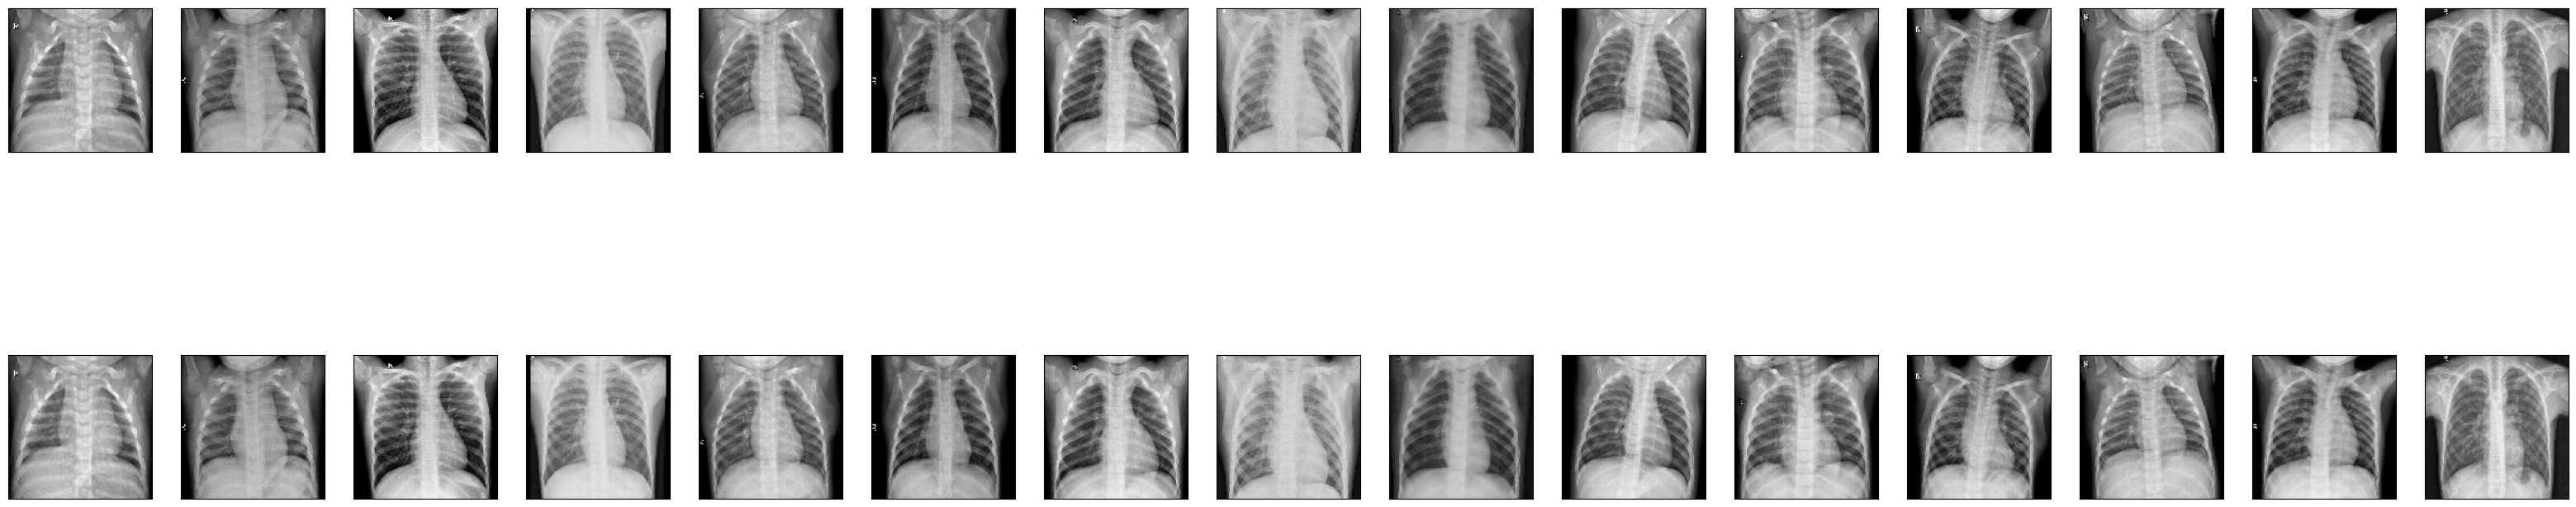

In [21]:

# Predicting decoded images
decoded_imgs = autoencoder.predict(X_test)

# Displaying original and reconstructed images
n = 15  
plt.figure(figsize=(40, 10))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


In [22]:
X_train, X_test = train_test_split(images, test_size=0.2, random_state=42)

In [23]:
encoder = autoencoder.get_layer("Encoder")
encoder.summary() 

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_11 (Conv2D)        │ (None, 64, 64, 32)     │            896 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_14    │ (None, 64, 64, 32)     │            128 │ conv2d_11[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_12 (Conv2D)        │ (None, 32, 32, 64)     │         18,496 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_15    │ (None, 32, 32, 64)     │            256 │ conv2d_12[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_13 (Conv2D)        │ (None, 32, 32, 64)     │         36,928 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_16    │ (None, 32, 32, 64)     │            256 │ conv2d_13[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_4 (Dropout)       │ (None, 32, 32, 64)     │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_14 (Conv2D)        │ (None, 32, 32, 64)     │         36,928 │ dropout_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_17    │ (None, 32, 32, 64)     │            256 │ conv2d_14[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_4 (Add)               │ (None, 32, 32, 64)     │              0 │ batch_normalization_1… │
│                           │                        │                │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_4 (Activation) │ (None, 32, 32, 64)     │              0 │ add_4[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_15 (Conv2D)        │ (None, 16, 16, 128)    │         73,856 │ activation_4[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_18    │ (None, 16, 16, 128)    │            512 │ conv2d_15[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_16 (Conv2D)        │ (None, 16, 16, 128)    │        147,584 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_19    │ (None, 16, 16, 128)    │            512 │ conv2d_16[0][0]        │
│ (BatchNormalization) 

 Total params: 464,704 (1.77 MB)

 Trainable params: 463,488 (1.77 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [24]:
fmaps_train = encoder.predict(X_train)
fmaps_test = encoder.predict(X_test)
def plot_feature_maps(feature_maps):
    num_maps = feature_maps.shape[-1]  
    grid_size = int(np.ceil(np.sqrt(num_maps))) 

    plt.figure(figsize=(15, 15))
    for i in range(num_maps):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

len(fmaps_train)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


1260

In [25]:
len(fmaps_test)

315